# <font color = darkblue> "Rajkumar Choudhary School of data Science and Forecasting."</font>

## <font color = darkred> Twitter tweets analysis.</font>


## Stage 1 :-  Find recent tweets using the keyword and store the raw data in log files.
### Write a program that takes keyword as input and finds recent tweets (100,000 tweets) containing that keyword using twitter’s official API and store the raw data (tweet JSON object) in log files ensuring that the log file should not exceed 10000 records or 5 Mb in size (whichever constraint is met first). You will have multiple log files for the raw data, choose naming convention for these files wisely as they will be reused in Stage 2. You can also use third party library as well (example - Tweepy for python).

# Importing Tweepy and other Libraries.

In [1]:
import tweepy
from tweepy import OAuthHandler
import csv
import pandas as pd
import json
from datetime import datetime
start_time=datetime.now()

## Initializing All the four important API keys for Tweet Analysis.

In [2]:
# all 4 authentication keys to access twitter API
# to connect as OAth handler or jump serever / revers proxy server
#consumer_key = "5wSytoAE1lu0H87ONJ0EoS5Rh"

consumer_key = "Z91q6yFBkJPUNJp629iYTofN1"
consumer_sec = "wWyAQft8jX9K1DyACL4Iy76ZEOVBLXKZOjGFfdNe4INCUvK4wX"
#consumer_sec = "4rGSGZEVbkxbv3mJgGhYKTfYFLM2quZSodWypy1zYf8JoN6FSU"
# from proxy server we need to connect
access_token = "1522505735115997184-P5EtO25YpRbCndgwxy1E6HlI6FA1v0"
access_token_sec = "ukHvdJYSCrLvN9YprXbNNpk8RDB8BWJs0CJKhHfeuaAIW"

### Define a function to Access the cunsumer key and Consumer Security key.

In [3]:
auth = tweepy.OAuthHandler(consumer_key,consumer_sec)

### By auth.set function Accessing the Access Token and Access Security Token.

In [4]:
auth.set_access_token(access_token,access_token_sec)

### Define API to connect to Strong API server of twitter.

In [5]:
api = tweepy.API(auth)

In [6]:
search_key = input('Please enter keyword or hashtag to search: ')     
no_of_tweet = input('Please enter how many tweets to analyze: ')   

Please enter keyword or hashtag to search: Data Science
Please enter how many tweets to analyze: 100


In [7]:
data = api.search_tweets(search_key,lang='en',count=no_of_tweet)

In [8]:
data[5]

Status(_api=<tweepy.api.API object at 0x00000236172D21F0>, _json={'created_at': 'Fri May 06 11:07:48 +0000 2022', 'id': 1522533583545675777, 'id_str': '1522533583545675777', 'text': 'RT @kdnuggets: How to Build Strong Data Science Portfolio as a Beginner\n#DataScience #KDnuggets \nhttps://t.co/AlPjb88cVc https://t.co/RtlGR…', 'truncated': False, 'entities': {'hashtags': [{'text': 'DataScience', 'indices': [72, 84]}, {'text': 'KDnuggets', 'indices': [85, 95]}], 'symbols': [], 'user_mentions': [{'screen_name': 'kdnuggets', 'name': 'KDnuggets', 'id': 20167623, 'id_str': '20167623', 'indices': [3, 13]}], 'urls': [{'url': 'https://t.co/AlPjb88cVc', 'expanded_url': 'https://www.kdnuggets.com/2021/10/strong-data-science-portfolio-as-beginner.html', 'display_url': 'kdnuggets.com/2021/10/strong…', 'indices': [97, 120]}]}, 'metadata': {'iso_language_code': 'en', 'result_type': 'recent'}, 'source': '<a href="https://mobile.twitter.com" rel="nofollow">Twitter Web App</a>', 'in_reply_to_status_id':

In [9]:
data.to_csv('rawdata.csv')

### To Create first json file.

In [10]:
d =[]
for i in data:
    status = i
    
    json_str = json.dumps(status._json)

    parsed = json.loads(json_str)

    json.dumps(parsed, indent=4, sort_keys=True)
    list = ['created_at','id_str','text','user','place','geo','coordinates','entities','source']
    
    d.append(dict((k, parsed[k]) for k in list))
    
with open('Stage1.json', 'w+') as f:          
    json.dump(d, f, indent=4)
    

## Stage 2 - Process and clean the raw data and save the processed data in log files.
### Process and clean the raw data stored in Stage 1 and store the processed data in new log files ensuring that the log file should not exceed 10000 records or 5 Mb in size (whichever constraint is met first). You will have multiple log files for the processed data, choose naming convention for these files wisely as they will be reused in Stage 3. You will have to create a new JSON object to store only relevant information in log files.



### Sorting the Tweets from last Cell data.

In [11]:
df=pd.read_json("Stage1.json")
df

,created_at,id_str,text,user,place,geo,coordinates,entities,source
0,2022-05-06 11:08:57+00:00,1522533875620016128,RT @SummerOkibe: MSc in Data Science Scholarsh...,"{'id': 3227797142, 'id_str': '3227797142', 'na...",NaN,NaN,NaN,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ..."
1,2022-05-06 11:08:35+00:00,1522533783513169920,Day 10: learning of data science\nStep 3: lear...,"{'id': 1424956166535192579, 'id_str': '1424956...",NaN,NaN,NaN,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ..."
2,2022-05-06 11:08:15+00:00,1522533698096472064,@nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...,"{'id': 1698265178, 'id_str': '1698265178', 'na...",NaN,NaN,NaN,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""https://mobile.twitter.com"" rel=""nofo..."
3,2022-05-06 11:08:02+00:00,1522533644061052928,"RT @TexasLindsay: ""When Art Meets Science"" - h...","{'id': 1519766883733581826, 'id_str': '1519766...",NaN,NaN,NaN,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ..."
4,2022-05-06 11:08:01+00:00,1522533638738436096,Are you able to access data that provides your...,"{'id': 1157231706778349568, 'id_str': '1157231...",NaN,NaN,NaN,"{'hashtags': [{'text': 'pilots', 'indices': [4...","<a href=""https://sproutsocial.com"" rel=""nofoll..."
...,...,...,...,...,...,...,...,...,...
95,2022-05-06 10:46:02+00:00,1522528106581573632,"Cocaine, meth at 'record availability' in EU: ...","{'id': 2716028982, 'id_str': '2716028982', 'na...",NaN,NaN,NaN,"{'hashtags': [{'text': '3Novices', 'indices': ...","<a href=""https://ifttt.com"" rel=""nofollow"">IFT..."
96,2022-05-06 10:45:34+00:00,1522527991020068864,RT @Paula_Piccard: The challenge of making dat...,"{'id': 1127829883013361665, 'id_str': '1127829...",NaN,NaN,NaN,"{'hashtags': [{'text': 'MachineLearning', 'ind...","<a href=""https://yathinbabu.github.io"" rel=""no..."
97,2022-05-06 10:45:31+00:00,1522527975702466560,RT @Paula_Piccard: The challenge of making dat...,"{'id': 1593780889, 'id_str': '1593780889', 'na...",NaN,NaN,NaN,"{'hashtags': [{'text': 'MachineLearning', 'ind...","<a href=""http://twitter.com/download/android"" ..."
98,2022-05-06 10:45:21+00:00,1522527934971617280,@TDataScience \nAloa! I'm looking for an artic...,"{'id': 26236774, 'id_str': '26236774', 'name':...",NaN,NaN,NaN,"{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""https://mobile.twitter.com"" rel=""nofo..."


In [12]:
df=df.dropna(axis='columns')
df

,created_at,id_str,text,user,entities,source
0,2022-05-06 11:08:57+00:00,1522533875620016128,RT @SummerOkibe: MSc in Data Science Scholarsh...,"{'id': 3227797142, 'id_str': '3227797142', 'na...","{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ..."
1,2022-05-06 11:08:35+00:00,1522533783513169920,Day 10: learning of data science\nStep 3: lear...,"{'id': 1424956166535192579, 'id_str': '1424956...","{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ..."
2,2022-05-06 11:08:15+00:00,1522533698096472064,@nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...,"{'id': 1698265178, 'id_str': '1698265178', 'na...","{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""https://mobile.twitter.com"" rel=""nofo..."
3,2022-05-06 11:08:02+00:00,1522533644061052928,"RT @TexasLindsay: ""When Art Meets Science"" - h...","{'id': 1519766883733581826, 'id_str': '1519766...","{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""http://twitter.com/download/android"" ..."
4,2022-05-06 11:08:01+00:00,1522533638738436096,Are you able to access data that provides your...,"{'id': 1157231706778349568, 'id_str': '1157231...","{'hashtags': [{'text': 'pilots', 'indices': [4...","<a href=""https://sproutsocial.com"" rel=""nofoll..."
...,...,...,...,...,...,...
95,2022-05-06 10:46:02+00:00,1522528106581573632,"Cocaine, meth at 'record availability' in EU: ...","{'id': 2716028982, 'id_str': '2716028982', 'na...","{'hashtags': [{'text': '3Novices', 'indices': ...","<a href=""https://ifttt.com"" rel=""nofollow"">IFT..."
96,2022-05-06 10:45:34+00:00,1522527991020068864,RT @Paula_Piccard: The challenge of making dat...,"{'id': 1127829883013361665, 'id_str': '1127829...","{'hashtags': [{'text': 'MachineLearning', 'ind...","<a href=""https://yathinbabu.github.io"" rel=""no..."
97,2022-05-06 10:45:31+00:00,1522527975702466560,RT @Paula_Piccard: The challenge of making dat...,"{'id': 1593780889, 'id_str': '1593780889', 'na...","{'hashtags': [{'text': 'MachineLearning', 'ind...","<a href=""http://twitter.com/download/android"" ..."
98,2022-05-06 10:45:21+00:00,1522527934971617280,@TDataScience \nAloa! I'm looking for an artic...,"{'id': 26236774, 'id_str': '26236774', 'name':...","{'hashtags': [], 'symbols': [], 'user_mentions...","<a href=""https://mobile.twitter.com"" rel=""nofo..."


In [13]:

DT = []
ID = []
U = []
T = []
P = []
E = []
R = []
for tweet in tweepy.Cursor(api.search_tweets, q=search_key, count=no_of_tweet,lang="en").items(100):
    print(tweet.created_at,tweet.id_str,tweet.user,tweet.text,tweet.source,tweet.entities,tweet.retweet_count)
    DT.append(tweet.created_at)
    ID.append(tweet.id_str)
    U.append(tweet.user)
    T.append(tweet.text)
    P.append(tweet.source)
    E.append(tweet.entities)
    R.append(tweet.retweet_count)


2022-05-06 11:08:57+00:00 1522533875620016128 User(_api=<tweepy.api.API object at 0x00000236172D21F0>, _json={'id': 3227797142, 'id_str': '3227797142', 'name': 'Touseef Hussain (He/Him)', 'screen_name': 'Hussaint789', 'location': 'New Delhi', 'description': 'ECR 🇮🇳, seeking new Opportunities-Phytopathology-(Fungi, Bacteria, Nematodes, Virus), Plant pathogens,🥔🍅🍊🔍🔬🦠🧬🧫🧪', 'url': 'https://t.co/4F5QciZ3PW', 'entities': {'url': {'urls': [{'url': 'https://t.co/4F5QciZ3PW', 'expanded_url': 'https://scholar.google.co.in/citations?user=wveFKCIAAAAJ&hl=en', 'display_url': 'scholar.google.co.in/citations?user…', 'indices': [0, 23]}]}, 'description': {'urls': []}}, 'protected': False, 'followers_count': 568, 'friends_count': 1708, 'listed_count': 7, 'created_at': 'Wed May 27 03:04:35 +0000 2015', 'favourites_count': 35568, 'utc_offset': None, 'time_zone': None, 'geo_enabled': True, 'verified': False, 'statuses_count': 12155, 'lang': None, 'contributors_enabled': False, 'is_translator': False, 'is_

In [14]:
data = pd.DataFrame({'Date and Time':DT, 'User id':ID,'UserName':U,'Tweet':T, 'URL':P,'Hashtags and Mention':E, 'No. of Retweet':R})
data


,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet
0,2022-05-06 11:08:57+00:00,1522533875620016128,User(_api=<tweepy.api.API object at 0x00000236...,RT @SummerOkibe: MSc in Data Science Scholarsh...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",80
1,2022-05-06 11:08:35+00:00,1522533783513169922,User(_api=<tweepy.api.API object at 0x00000236...,Day 10: learning of data science\nStep 3: lear...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
2,2022-05-06 11:08:15+00:00,1522533698096472064,User(_api=<tweepy.api.API object at 0x00000236...,@nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
3,2022-05-06 11:08:02+00:00,1522533644061052931,User(_api=<tweepy.api.API object at 0x00000236...,"RT @TexasLindsay: ""When Art Meets Science"" - h...",Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",495
4,2022-05-06 11:08:01+00:00,1522533638738436097,User(_api=<tweepy.api.API object at 0x00000236...,Are you able to access data that provides your...,Sprout Social,"{'hashtags': [{'text': 'pilots', 'indices': [4...",0
...,...,...,...,...,...,...,...
95,2022-05-06 10:46:02+00:00,1522528106581573632,User(_api=<tweepy.api.API object at 0x00000236...,"Cocaine, meth at 'record availability' in EU: ...",IFTTT,"{'hashtags': [{'text': '3Novices', 'indices': ...",0
96,2022-05-06 10:45:34+00:00,1522527991020068864,User(_api=<tweepy.api.API object at 0x00000236...,RT @Paula_Piccard: The challenge of making dat...,xael bot,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22
97,2022-05-06 10:45:31+00:00,1522527975702466564,User(_api=<tweepy.api.API object at 0x00000236...,RT @Paula_Piccard: The challenge of making dat...,Twitter for Android,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22
98,2022-05-06 10:45:21+00:00,1522527934971617282,User(_api=<tweepy.api.API object at 0x00000236...,@TDataScience \nAloa! I'm looking for an artic...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0


In [15]:
data[("Tweet")]

0     RT @SummerOkibe: MSc in Data Science Scholarsh...
1     Day 10: learning of data science\nStep 3: lear...
2     @nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...
3     RT @TexasLindsay: "When Art Meets Science" - h...
4     Are you able to access data that provides your...
                            ...                        
95    Cocaine, meth at 'record availability' in EU: ...
96    RT @Paula_Piccard: The challenge of making dat...
97    RT @Paula_Piccard: The challenge of making dat...
98    @TDataScience \nAloa! I'm looking for an artic...
99    RT @WSWS_Updates: Ariel Karlinsky is a graduat...
Name: Tweet, Length: 100, dtype: object

In [16]:
data.head()

,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet
0,2022-05-06 11:08:57+00:00,1522533875620016128,User(_api=<tweepy.api.API object at 0x00000236...,RT @SummerOkibe: MSc in Data Science Scholarsh...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",80
1,2022-05-06 11:08:35+00:00,1522533783513169922,User(_api=<tweepy.api.API object at 0x00000236...,Day 10: learning of data science\nStep 3: lear...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
2,2022-05-06 11:08:15+00:00,1522533698096472064,User(_api=<tweepy.api.API object at 0x00000236...,@nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
3,2022-05-06 11:08:02+00:00,1522533644061052931,User(_api=<tweepy.api.API object at 0x00000236...,"RT @TexasLindsay: ""When Art Meets Science"" - h...",Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",495
4,2022-05-06 11:08:01+00:00,1522533638738436097,User(_api=<tweepy.api.API object at 0x00000236...,Are you able to access data that provides your...,Sprout Social,"{'hashtags': [{'text': 'pilots', 'indices': [4...",0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   Date and Time         100 non-null    datetime64[ns, UTC]
 1   User id               100 non-null    object             
 2   UserName              100 non-null    object             
 3   Tweet                 100 non-null    object             
 4   URL                   100 non-null    object             
 5   Hashtags and Mention  100 non-null    object             
 6   No. of Retweet        100 non-null    int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(5)
memory usage: 5.6+ KB


In [18]:
data.dtypes

Date and Time           datetime64[ns, UTC]
User id                              object
UserName                             object
Tweet                                object
URL                                  object
Hashtags and Mention                 object
No. of Retweet                        int64
dtype: object

In [19]:
data.notnull()

,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet
0,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...
95,True,True,True,True,True,True,True
96,True,True,True,True,True,True,True
97,True,True,True,True,True,True,True
98,True,True,True,True,True,True,True


In [20]:
data.nunique

<bound method DataFrame.nunique of                Date and Time              User id  \
0  2022-05-06 11:08:57+00:00  1522533875620016128   
1  2022-05-06 11:08:35+00:00  1522533783513169922   
2  2022-05-06 11:08:15+00:00  1522533698096472064   
3  2022-05-06 11:08:02+00:00  1522533644061052931   
4  2022-05-06 11:08:01+00:00  1522533638738436097   
..                       ...                  ...   
95 2022-05-06 10:46:02+00:00  1522528106581573632   
96 2022-05-06 10:45:34+00:00  1522527991020068864   
97 2022-05-06 10:45:31+00:00  1522527975702466564   
98 2022-05-06 10:45:21+00:00  1522527934971617282   
99 2022-05-06 10:43:35+00:00  1522527491327410176   

                                             UserName  \
0   User(_api=<tweepy.api.API object at 0x00000236...   
1   User(_api=<tweepy.api.API object at 0x00000236...   
2   User(_api=<tweepy.api.API object at 0x00000236...   
3   User(_api=<tweepy.api.API object at 0x00000236...   
4   User(_api=<tweepy.api.API object at 0x0

In [21]:
for tweet in data:
      print(data.Tweet)

0     RT @SummerOkibe: MSc in Data Science Scholarsh...
1     Day 10: learning of data science\nStep 3: lear...
2     @nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...
3     RT @TexasLindsay: "When Art Meets Science" - h...
4     Are you able to access data that provides your...
                            ...                        
95    Cocaine, meth at 'record availability' in EU: ...
96    RT @Paula_Piccard: The challenge of making dat...
97    RT @Paula_Piccard: The challenge of making dat...
98    @TDataScience \nAloa! I'm looking for an artic...
99    RT @WSWS_Updates: Ariel Karlinsky is a graduat...
Name: Tweet, Length: 100, dtype: object
0     RT @SummerOkibe: MSc in Data Science Scholarsh...
1     Day 10: learning of data science\nStep 3: lear...
2     @nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...
3     RT @TexasLindsay: "When Art Meets Science" - h...
4     Are you able to access data that provides your...
                            ...                        
95    Co

### Remove URL.

In [22]:
import re

def remove_URL(text):
    return re.sub(r"http\S+", "",str(text))

In [23]:
data['Tweet']= data['Tweet'].apply(remove_URL)
data['Tweet']

0     RT @SummerOkibe: MSc in Data Science Scholarsh...
1     Day 10: learning of data science\nStep 3: lear...
2     @nanyajita @Berugi98 @SleepyHeartss @sadgrlcin...
3     RT @TexasLindsay: "When Art Meets Science" - h...
4     Are you able to access data that provides your...
                            ...                        
95    Cocaine, meth at 'record availability' in EU: ...
96    RT @Paula_Piccard: The challenge of making dat...
97    RT @Paula_Piccard: The challenge of making dat...
98    @TDataScience \nAloa! I'm looking for an artic...
99    RT @WSWS_Updates: Ariel Karlinsky is a graduat...
Name: Tweet, Length: 100, dtype: object

### Remove Mention.

In [24]:
def remove_Mention(Tweet):
    return re.sub(r"@\S+", "",str(Tweet))

In [25]:
data['Tweet']= data['Tweet'].apply(remove_Mention)
data['Tweet']

0     RT  MSc in Data Science Scholarships, Universi...
1     Day 10: learning of data science\nStep 3: lear...
2         body language experts on yt be foolin ever...
3     RT  "When Art Meets Science" - how a doctor on...
4     Are you able to access data that provides your...
                            ...                        
95    Cocaine, meth at 'record availability' in EU: ...
96    RT  The challenge of making data science zero-...
97    RT  The challenge of making data science zero-...
98     \nAloa! I'm looking for an article: "Perform ...
99    RT  Ariel Karlinsky is a graduate student in e...
Name: Tweet, Length: 100, dtype: object

### Remove Reserved Word RT and FAV.

In [26]:
def remove_Reserved_Word(Tweet):
    return re.sub(r"RT/FAV", "",str(Tweet))

In [27]:
data['Tweet']= data['Tweet'].apply(remove_Reserved_Word)
data['Tweet']

0     RT  MSc in Data Science Scholarships, Universi...
1     Day 10: learning of data science\nStep 3: lear...
2         body language experts on yt be foolin ever...
3     RT  "When Art Meets Science" - how a doctor on...
4     Are you able to access data that provides your...
                            ...                        
95    Cocaine, meth at 'record availability' in EU: ...
96    RT  The challenge of making data science zero-...
97    RT  The challenge of making data science zero-...
98     \nAloa! I'm looking for an article: "Perform ...
99    RT  Ariel Karlinsky is a graduate student in e...
Name: Tweet, Length: 100, dtype: object

### Remove punctuation and special character.

In [28]:
def remove_punctuation(Tweet):
    new_words = []
    for word in Tweet:
        new_word = re.sub(r"[^\w\s]", "", str(Tweet))
        if new_word != '':
            new_words.append(new_word)
    return new_words

In [29]:
data['Tweet']=data['Tweet'].apply(remove_punctuation)
data['Tweet']

0     [RT  MSc in Data Science Scholarships Universi...
1     [Day 10 learning of data science\nStep 3 learn...
2     [    body language experts on yt be foolin eve...
3     [RT  When Art Meets Science  how a doctor on t...
4     [Are you able to access data that provides you...
                            ...                        
95    [Cocaine meth at record availability in EU rep...
96    [RT  The challenge of making data science zero...
97    [RT  The challenge of making data science zero...
98    [ \nAloa Im looking for an article Perform a D...
99    [RT  Ariel Karlinsky is a graduate student in ...
Name: Tweet, Length: 100, dtype: object

In [30]:
data.to_json('Stage2.json')

In [31]:
data.to_csv("Final.csv")

## Stage 3 - Perform following tasks on processed data ""Sentimental Analysis.""
#### Use the processed data of the Stage 2 and write program to find solutions to following sub problems.

In [32]:
dt =pd.read_csv('Final.csv')

In [33]:
dt

,Unnamed: 0,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet
0,0,2022-05-06 11:08:57+00:00,1522533875620016128,User(_api=<tweepy.api.API object at 0x00000236...,['RT MSc in Data Science Scholarships Univers...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",80
1,1,2022-05-06 11:08:35+00:00,1522533783513169922,User(_api=<tweepy.api.API object at 0x00000236...,['Day 10 learning of data science\nStep 3 lear...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
2,2,2022-05-06 11:08:15+00:00,1522533698096472064,User(_api=<tweepy.api.API object at 0x00000236...,[' body language experts on yt be foolin ev...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
3,3,2022-05-06 11:08:02+00:00,1522533644061052931,User(_api=<tweepy.api.API object at 0x00000236...,['RT When Art Meets Science how a doctor on ...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",495
4,4,2022-05-06 11:08:01+00:00,1522533638738436097,User(_api=<tweepy.api.API object at 0x00000236...,['Are you able to access data that provides yo...,Sprout Social,"{'hashtags': [{'text': 'pilots', 'indices': [4...",0
...,...,...,...,...,...,...,...,...
95,95,2022-05-06 10:46:02+00:00,1522528106581573632,User(_api=<tweepy.api.API object at 0x00000236...,['Cocaine meth at record availability in EU re...,IFTTT,"{'hashtags': [{'text': '3Novices', 'indices': ...",0
96,96,2022-05-06 10:45:34+00:00,1522527991020068864,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,xael bot,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22
97,97,2022-05-06 10:45:31+00:00,1522527975702466564,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,Twitter for Android,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22
98,98,2022-05-06 10:45:21+00:00,1522527934971617282,User(_api=<tweepy.api.API object at 0x00000236...,[' \nAloa Im looking for an article Perform a ...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0


## Problem A - Generate word cloud
### Find the count of each word in the entire data set of tweet texts and save the result in csv format in descending order of count.

### Creating word cloud on data which is filtered from Twitter by our Specific Key. <font color = red> ""Travelling"" </font>

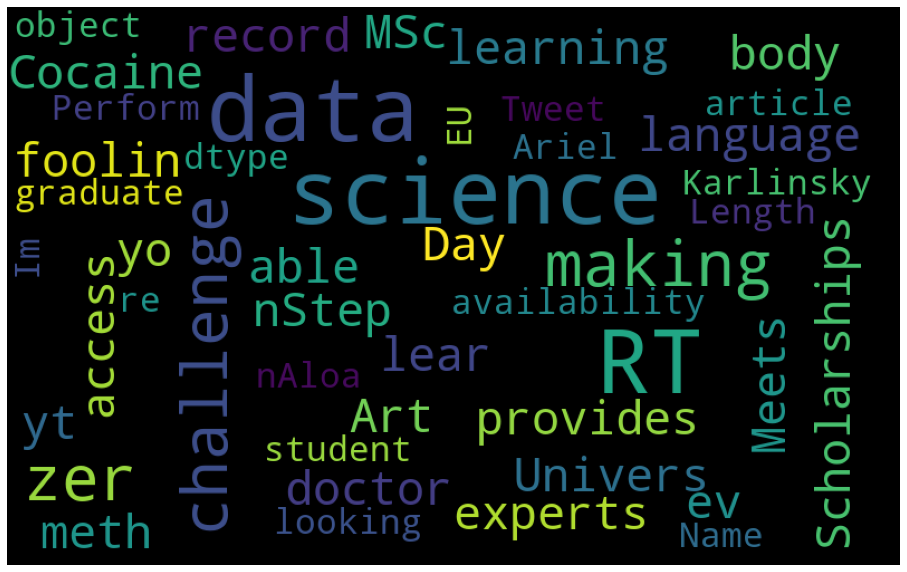

In [34]:
import matplotlib.pyplot as plt 
from wordcloud import WordCloud
wordcloud = WordCloud( width = 800, height = 500, max_font_size=80, background_color= 'Black', max_words= 5000).generate(str(dt.Tweet))
plt.figure(figsize = (16,16))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## Problem B - Create Inverted Index
### Write a program that produces an inverted index that gives, for every hashtag, the list of tweet ids it appears in and save the data in the log file.You will have to create a new JSON object to store only relevant information in the log file. Also enable index search so that a user can search, for a hashtag, the list of tweet ids.

In [35]:
dt.to_json("Stage3.json")

In [36]:
d = pd.read_json("Stage3.json")
d

,Unnamed: 0,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet
0,0,2022-05-06 11:08:57+00:00,1522533875620016128,User(_api=<tweepy.api.API object at 0x00000236...,['RT MSc in Data Science Scholarships Univers...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",80
1,1,2022-05-06 11:08:35+00:00,1522533783513169922,User(_api=<tweepy.api.API object at 0x00000236...,['Day 10 learning of data science\nStep 3 lear...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
2,2,2022-05-06 11:08:15+00:00,1522533698096472064,User(_api=<tweepy.api.API object at 0x00000236...,[' body language experts on yt be foolin ev...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0
3,3,2022-05-06 11:08:02+00:00,1522533644061052931,User(_api=<tweepy.api.API object at 0x00000236...,['RT When Art Meets Science how a doctor on ...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",495
4,4,2022-05-06 11:08:01+00:00,1522533638738436097,User(_api=<tweepy.api.API object at 0x00000236...,['Are you able to access data that provides yo...,Sprout Social,"{'hashtags': [{'text': 'pilots', 'indices': [4...",0
...,...,...,...,...,...,...,...,...
95,95,2022-05-06 10:46:02+00:00,1522528106581573632,User(_api=<tweepy.api.API object at 0x00000236...,['Cocaine meth at record availability in EU re...,IFTTT,"{'hashtags': [{'text': '3Novices', 'indices': ...",0
96,96,2022-05-06 10:45:34+00:00,1522527991020068864,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,xael bot,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22
97,97,2022-05-06 10:45:31+00:00,1522527975702466564,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,Twitter for Android,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22
98,98,2022-05-06 10:45:21+00:00,1522527934971617282,User(_api=<tweepy.api.API object at 0x00000236...,[' \nAloa Im looking for an article Perform a ...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0


In [37]:
d.nunique

<bound method DataFrame.nunique of     Unnamed: 0              Date and Time              User id  \
0            0  2022-05-06 11:08:57+00:00  1522533875620016128   
1            1  2022-05-06 11:08:35+00:00  1522533783513169922   
2            2  2022-05-06 11:08:15+00:00  1522533698096472064   
3            3  2022-05-06 11:08:02+00:00  1522533644061052931   
4            4  2022-05-06 11:08:01+00:00  1522533638738436097   
..         ...                        ...                  ...   
95          95  2022-05-06 10:46:02+00:00  1522528106581573632   
96          96  2022-05-06 10:45:34+00:00  1522527991020068864   
97          97  2022-05-06 10:45:31+00:00  1522527975702466564   
98          98  2022-05-06 10:45:21+00:00  1522527934971617282   
99          99  2022-05-06 10:43:35+00:00  1522527491327410176   

                                             UserName  \
0   User(_api=<tweepy.api.API object at 0x00000236...   
1   User(_api=<tweepy.api.API object at 0x00000236...   
2

## Problem C - Perform Sentiment Analysis and publish distribution by place
### Write a program that tells you whether a tweet expresses a positive sentiment, negative sentiment or its neutral and publish the distribution of result by place in csv file.


In [38]:
from textblob import TextBlob
def sentiment(Tweet):
    return TextBlob(Tweet).sentiment.subjectivity

def polarity(Tweet):
    return TextBlob(Tweet).sentiment.polarity

dt['sentiment']= dt['Tweet'].apply(sentiment)
dt['polarity']= dt['Tweet'].apply(polarity)

dt

,Unnamed: 0,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet,sentiment,polarity
0,0,2022-05-06 11:08:57+00:00,1522533875620016128,User(_api=<tweepy.api.API object at 0x00000236...,['RT MSc in Data Science Scholarships Univers...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",80,0.000000,0.000
1,1,2022-05-06 11:08:35+00:00,1522533783513169922,User(_api=<tweepy.api.API object at 0x00000236...,['Day 10 learning of data science\nStep 3 lear...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",0,0.000000,0.000
2,2,2022-05-06 11:08:15+00:00,1522533698096472064,User(_api=<tweepy.api.API object at 0x00000236...,[' body language experts on yt be foolin ev...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0,0.650000,0.350
3,3,2022-05-06 11:08:02+00:00,1522533644061052931,User(_api=<tweepy.api.API object at 0x00000236...,['RT When Art Meets Science how a doctor on ...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",495,0.558333,0.225
4,4,2022-05-06 11:08:01+00:00,1522533638738436097,User(_api=<tweepy.api.API object at 0x00000236...,['Are you able to access data that provides yo...,Sprout Social,"{'hashtags': [{'text': 'pilots', 'indices': [4...",0,0.375000,0.250
...,...,...,...,...,...,...,...,...,...,...
95,95,2022-05-06 10:46:02+00:00,1522528106581573632,User(_api=<tweepy.api.API object at 0x00000236...,['Cocaine meth at record availability in EU re...,IFTTT,"{'hashtags': [{'text': '3Novices', 'indices': ...",0,0.000000,0.000
96,96,2022-05-06 10:45:34+00:00,1522527991020068864,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,xael bot,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22,0.500000,0.500
97,97,2022-05-06 10:45:31+00:00,1522527975702466564,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,Twitter for Android,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22,0.500000,0.500
98,98,2022-05-06 10:45:21+00:00,1522527934971617282,User(_api=<tweepy.api.API object at 0x00000236...,[' \nAloa Im looking for an article Perform a ...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0,0.000000,0.000


In [39]:
def sentiment_analysis(x):
    if x > 0:
        return 'pos'
    elif x < 0:
        return 'neg'
    else:
        return 'ne'
    
dt['sentiment_analysis'] = dt['polarity'].apply(sentiment_analysis)
dt

,Unnamed: 0,Date and Time,User id,UserName,Tweet,URL,Hashtags and Mention,No. of Retweet,sentiment,polarity,sentiment_analysis
0,0,2022-05-06 11:08:57+00:00,1522533875620016128,User(_api=<tweepy.api.API object at 0x00000236...,['RT MSc in Data Science Scholarships Univers...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",80,0.000000,0.000,ne
1,1,2022-05-06 11:08:35+00:00,1522533783513169922,User(_api=<tweepy.api.API object at 0x00000236...,['Day 10 learning of data science\nStep 3 lear...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",0,0.000000,0.000,ne
2,2,2022-05-06 11:08:15+00:00,1522533698096472064,User(_api=<tweepy.api.API object at 0x00000236...,[' body language experts on yt be foolin ev...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0,0.650000,0.350,pos
3,3,2022-05-06 11:08:02+00:00,1522533644061052931,User(_api=<tweepy.api.API object at 0x00000236...,['RT When Art Meets Science how a doctor on ...,Twitter for Android,"{'hashtags': [], 'symbols': [], 'user_mentions...",495,0.558333,0.225,pos
4,4,2022-05-06 11:08:01+00:00,1522533638738436097,User(_api=<tweepy.api.API object at 0x00000236...,['Are you able to access data that provides yo...,Sprout Social,"{'hashtags': [{'text': 'pilots', 'indices': [4...",0,0.375000,0.250,pos
...,...,...,...,...,...,...,...,...,...,...,...
95,95,2022-05-06 10:46:02+00:00,1522528106581573632,User(_api=<tweepy.api.API object at 0x00000236...,['Cocaine meth at record availability in EU re...,IFTTT,"{'hashtags': [{'text': '3Novices', 'indices': ...",0,0.000000,0.000,ne
96,96,2022-05-06 10:45:34+00:00,1522527991020068864,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,xael bot,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22,0.500000,0.500,pos
97,97,2022-05-06 10:45:31+00:00,1522527975702466564,User(_api=<tweepy.api.API object at 0x00000236...,['RT The challenge of making data science zer...,Twitter for Android,"{'hashtags': [{'text': 'MachineLearning', 'ind...",22,0.500000,0.500,pos
98,98,2022-05-06 10:45:21+00:00,1522527934971617282,User(_api=<tweepy.api.API object at 0x00000236...,[' \nAloa Im looking for an article Perform a ...,Twitter Web App,"{'hashtags': [], 'symbols': [], 'user_mentions...",0,0.000000,0.000,ne


## Difference in time taken by programs to run by use of Parallel Processing.

In [40]:
end_time=datetime.now()
print('Duration: {}'.format(end_time-start_time))

Duration: 0:00:17.572095


### Thankyou....